Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-16 20:27:30.435134: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/4
351/351 ━━━━━━━━━━━━━━━━━━━━ 296s 834ms/step - accuracy: 0.4606 - loss: 1.3340 - val_accuracy: 0.5974 - val_loss: 1.0465
Epoch 2/4
351/351 ━━━━━━━━━━━━━━━━━━━━ 284s 807ms/step - accuracy: 0.6295 - loss: 0.9765 - val_accuracy: 0.7115 - val_loss: 0.7940
Epoch 3/4
351/351 ━━━━━━━━━━━━━━━━━━━━ 282s 804ms/step - accuracy: 0.6905 - loss: 0.8405 - val_accuracy: 0.7543 - val_loss: 0.6973
Epoch 4/4
351/351 ━━━━━━━━━━━━━━━━━━━━ 281s 801ms/step - accuracy: 0.7145 - loss: 0.7798 - val_accuracy: 0.7557 - val_loss: 0.6919
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Predicted Class Name: street
Predicted Class Index: 5
All Class Names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
True Label (One-hot): [0. 0. 0. 0. 0. 1.]


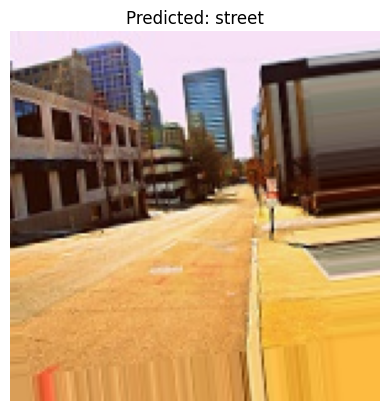

In [2]:
# ✅ Intel Image Classification using CNN (Keras + TensorFlow)
# Author: Huzefa
# Dataset: Intel Image Classification (6 classes)
# Description: CNN model to classify images from 6 terrain categories.

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📦 1. Import Required Libraries
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📁 2. Set Dataset Path
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
path = '/kaggle/input/intel-image-classification/seg_train/seg_train'

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔄 3. Image Augmentation and Data Generators
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_datagen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=30,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

# 🏋️ Training data generator
train_gen = train_datagen.flow_from_directory(
    path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# 🧪 Validation data generator
test_gen = train_datagen.flow_from_directory(
    path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🧠 4. Build CNN Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')  # 6 output neurons for 6 classes
])

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ⚙️ 5. Compile the Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📈 6. Train the Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model.fit(train_gen, validation_data=test_gen, epochs=4)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔍 7. Evaluate a Single Image from Validation Set
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Load one batch of images and labels
images, labels = test_gen[0]  # First batch

# Class names from the data generator
class_names = list(test_gen.class_indices.keys())

# Pick an image index to test
index = 12

# Predict the class
pred = model.predict(np.expand_dims(images[index], axis=0))
pred_class = np.argmax(pred)

# Show the prediction results
print(f"Predicted Class Name: {class_names[pred_class]}")
print(f"Predicted Class Index: {pred_class}")
print(f"All Class Names: {class_names}")
print(f"True Label (One-hot): {labels[index]}")

# Show the image
plt.imshow(images[index])
plt.title(f"Predicted: {class_names[pred_class]}")
plt.axis('off')
plt.show()
